# 降维

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

# 降维算法
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits, fetch_openml
from sklearn.preprocessing import StandardScaler

# 用于评估
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

# 美化
# plt.style.use('seaborn-v0_8-darkgrid')
# sns.set_palette("husl")
# %matplotlib inline

# 检查UMAP是否可用
try:
    import umap
    from umap import UMAP
    UMAP_AVAILABLE = True
    print("UMAP已安装")
except ImportError:
    UMAP_AVAILABLE = False
    print("UMAP未安装，跳过UMAP示例")

UMAP未安装，跳过UMAP示例


特征矩阵形状: (1797, 64)
标签形状: (1797,)
特征维度: 64
类别: [0 1 2 3 4 5 6 7 8 9]


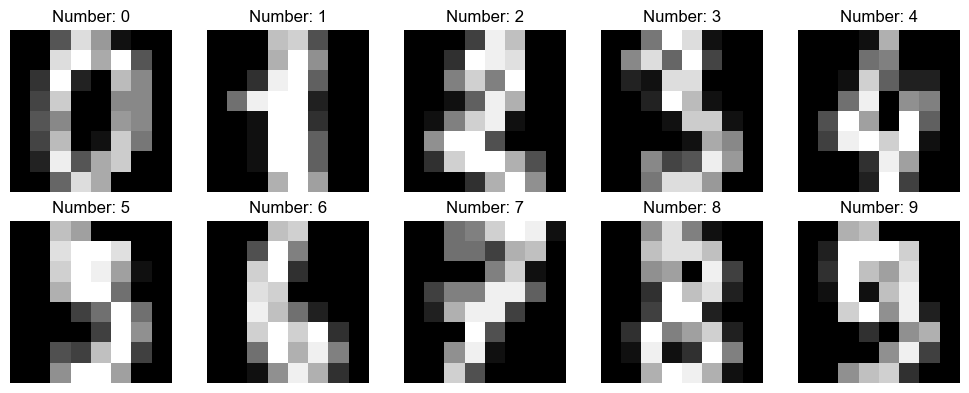

In [7]:
 # 加载数据
digits = load_digits()
X = digits.data      # 1797个样本，64个特征 (8x8像素)
y = digits.target    # 标签 0-9

print(f"特征矩阵形状: {X.shape}")
print(f"标签形状: {y.shape}")
print(f"特征维度: {X.shape[1]}")
print(f"类别: {np.unique(y)}")

# 显示几个数字图片
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Number: {y[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [8]:
# 标准化（PCA对尺度敏感）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"标准化前 - 均值: {X.mean():.2f}, 标准差: {X.std():.2f}")
print(f"标准化后 - 均值: {X_scaled.mean():.2f}, 标准差: {X_scaled.std():.2f}")

标准化前 - 均值: 4.88, 标准差: 6.02
标准化后 - 均值: 0.00, 标准差: 0.98


## PCA降维

降维后形状: (1797, 2)
解释方差比: [0.12033916 0.09561054]
累计解释方差: 21.59%


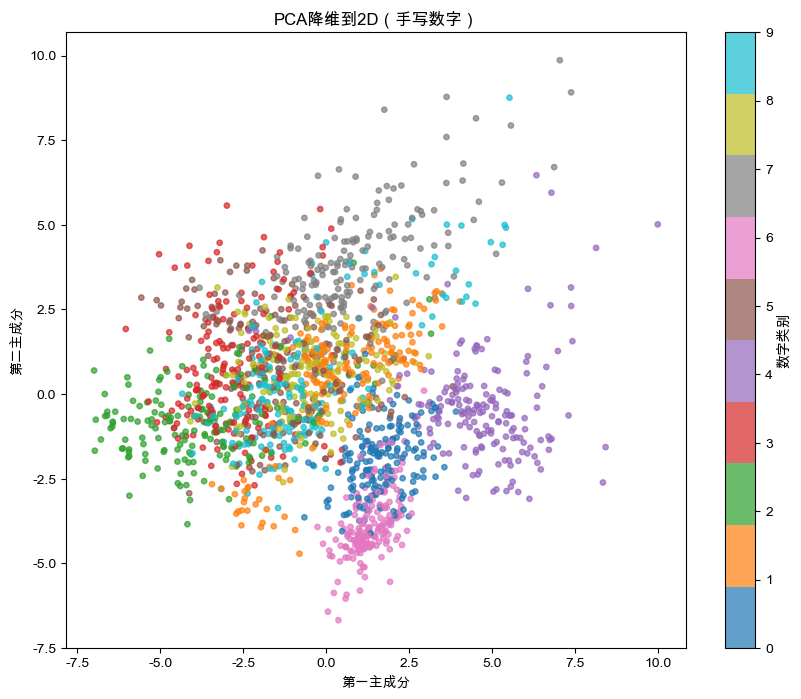

In [9]:
# 先降到2维用于可视化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"降维后形状: {X_pca.shape}")
print(f"解释方差比: {pca.explained_variance_ratio_}")
print(f"累计解释方差: {pca.explained_variance_ratio_.sum():.2%}")

# 可视化
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, label='数字类别')
plt.xlabel('第一主成分')
plt.ylabel('第二主成分')
plt.title('PCA降维到2D（手写数字）')
plt.show()

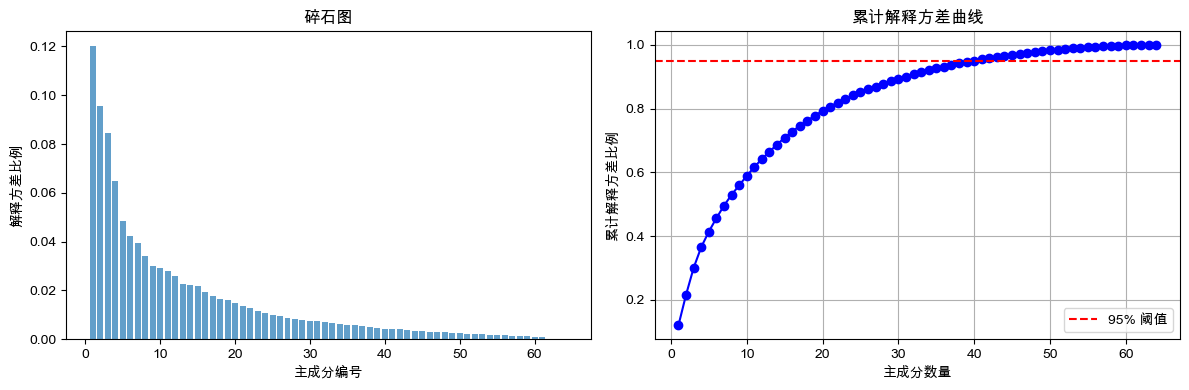

保留95%信息需要的维度数: 40
原始维度: 64, 压缩率: 1.6倍


In [10]:
# 计算不同维度下的累计解释方差
pca_full = PCA()
pca_full.fit(X_scaled)

# 绘制碎石图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：每个主成分的解释方差
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1), 
            pca_full.explained_variance_ratio_, alpha=0.7)
axes[0].set_xlabel('主成分编号')
axes[0].set_ylabel('解释方差比例')
axes[0].set_title('碎石图')

# 右图：累计解释方差
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumsum)+1), cumsum, 'bo-')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% 阈值')
axes[1].set_xlabel('主成分数量')
axes[1].set_ylabel('累计解释方差比例')
axes[1].set_title('累计解释方差曲线')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 找到达到95%所需的维度
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f"保留95%信息需要的维度数: {n_95}")
print(f"原始维度: 64, 压缩率: {64/n_95:.1f}倍")

## t-SNE 计算较慢(如硬件不够会报错)

In [11]:
# t-SNE 计算较慢，这里只用部分数据演示
# n_samples = 100
# np.random.seed(42)
# indices = np.random.choice(len(X_scaled), n_samples, replace=False)
# X_sample = X_scaled[indices]
# y_sample = y[indices]

In [12]:
# print("t-SNE 降维中...")
# start_time = time()
# tsne = TSNE(n_components=2, random_state=42, perplexity=10)
# X_tsne = tsne.fit_transform(X_sample)
# print(f"耗时: {time() - start_time:.2f} 秒")

In [13]:
# 可视化
# plt.figure(figsize=(10, 8))
# scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab10', s=20, alpha=0.7)
# plt.colorbar(scatter, label='数字类别')
# plt.xlabel('t-SNE 维度1')
# plt.ylabel('t-SNE 维度2')
# plt.title('t-SNE 降维结果（500个样本）')
# plt.show()

## 评估降维对分类任务的影响

In [14]:
# 比较原始特征 vs PCA降维后的分类准确率
pca_30 = PCA(n_components=30)  # 保留30个主成分
X_pca30 = pca_30.fit_transform(X_scaled)

# 原始数据
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
acc_original = accuracy_score(y_test, knn.predict(X_test))

# PCA降维后
X_train_pca, X_test_pca = train_test_split(X_pca30, test_size=0.2, random_state=42)
# 需要对齐训练集和测试集的索引
_, X_test_pca, _, y_test = train_test_split(X_pca30, y, test_size=0.2, random_state=42)
knn.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, knn.predict(X_test_pca))

print(f"原始特征 (64维) 分类准确率: {acc_original:.2%}")
print(f"PCA降维 (30维) 分类准确率: {acc_pca:.2%}")
print(f"维度减少: {64} → 30 (压缩 {(1-30/64)*100:.0f}%)")
print(f"准确率变化: {(acc_pca - acc_original)*100:+.2f}%")

: 